<a href="https://colab.research.google.com/github/Tejusetty/-iaffine-y-coordinate-of-mP/blob/main/Image_encryption.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install numpy pillow -q

In [ ]:
from google.colab import files
uploaded = files.upload()
image_path = list(uploaded.keys())[0]

Saving monalisa pic.jpg to monalisa pic.jpg


In [ ]:
import numpy as np
from PIL import Image, ImageDraw
import sys


def split_base_p(n, p):
    p2 = p * p
    n %= p2
    return n % p, (n // p) % p


def paper_even_from_digits(Xm0, Xm1, Zm0, Zm1, A, B, p):
    p2 = p * p
    Xk = (
        (Xm0*Xm0 + (p-1)*A*Zm0*Zm0)**2
        + 8*B*(p-1)*Xm0*(Zm0**3)
        + (
            2*(Xm0*Xm0 + (p-1)*A*Zm0*Zm0)
            * (2*Xm0*Xm1 + A*(p-1)*(Zm0*Zm0 + 2*Zm0*Zm1))
            + 8*B*(p-1)*(Xm0*(Zm0**3) + Xm1*(Zm0**3) + 3*(Zm0**2)*Zm1*Xm0)
        ) * p
    ) % p2
    Zk = (
        4*Zm0*(Xm0**3 + A*Xm0*(Zm0**2) + B*(Zm0**3))
        + (
            4*Zm0*(3*(Xm0**2)*Xm1 + A*(Zm0**2)*Xm1 + 2*A*Xm0*Zm0*Zm1 + 3*B*(Zm0**2)*Zm1)
            + 4*Zm1*(Xm0**3 + A*Xm0*(Zm0**2) + B*(Zm0**3))
        ) * p
    ) % p2
    return split_base_p(Xk, p), split_base_p(Zk, p), Xk, Zk


def paper_odd_from_digits(Xm0, Xm1, Xmp0, Xmp1, Zm0, Zm1, Zmp0, Zmp1, C0, C1, A, B, p):
    p2 = p * p
    termA = (Xm0*Zmp0 + Xmp0*Zm0) % p2
    base  = (Xm0*Xmp0 + (p-1)*A*Zm0*Zmp0) % p2
    Xk = (
        (4*B*(p-1)*termA*Zm0*Zmp0 + (base*base) % p2)
        + (
            4*B*(p-1)*(
                termA*(Zm0*Zmp1 + Zm1*Zmp0)
                + Zm0*Zmp0*(Xm0*Zmp1 + Xm1*Zmp0 + Xmp0*Zm1 + Xmp1*Zm0)
            )
            + 4*B*(p-1)*termA*Zm0*Zmp0
            + 2*base*(Xm0*Xmp1 + Xm1*Xmp0 + A*(p-1)*(Zm0*Zmp1 + Zm1*Zmp0 + Zm0*Zmp0))
        ) * p
    ) % p2
    baseZ = (Xm0*Zmp0 + (p-1)*Xmp0*Zm0) % p2
    Zk = (
        (C0 * ((baseZ*baseZ) % p2))
        + (
            C1 * ((baseZ*baseZ) % p2)
            + 2*C0*baseZ*(Xm0*Zmp1 + Xm1*Zmp0 + (p-1)*(Xmp0*Zm1 + Xmp1*Zm0 + Xmp0*Zm0))
        ) * p
    ) % p2
    return split_base_p(Xk, p), split_base_p(Zk, p), Xk, Zk


def scalar_mult(n, Px, Pz, A, B, p):
    p2 = p * p
    if n == 0: return 0, 0
    if n == 1: return Px % p2, Pz % p2
    X0, Z0 = Px % p2, Pz % p2
    X0d, Z0d = split_base_p(X0, p), split_base_p(Z0, p)
    _, _, X1, Z1 = paper_even_from_digits(X0d[0], X0d[1], Z0d[0], Z0d[1], A, B, p)
    X1 %= p2; Z1 %= p2
    C0, C1 = split_base_p(Pz % p2, p)
    for bit in bin(n)[3:]:
        x0a, x0b = split_base_p(X0, p); z0a, z0b = split_base_p(Z0, p)
        x1a, x1b = split_base_p(X1, p); z1a, z1b = split_base_p(Z1, p)
        if bit == '0':
            _, _, X1, Z1 = paper_odd_from_digits(x0a,x0b,x1a,x1b,z0a,z0b,z1a,z1b,C0,C1,A,B,p)
            _, _, X0, Z0 = paper_even_from_digits(x0a,x0b,z0a,z0b,A,B,p)
        else:
            _, _, X0, Z0 = paper_odd_from_digits(x0a,x0b,x1a,x1b,z0a,z0b,z1a,z1b,C0,C1,A,B,p)
            _, _, X1, Z1 = paper_even_from_digits(x1a,x1b,z1a,z1b,A,B,p)
        X0 %= p2; Z0 %= p2; X1 %= p2; Z1 %= p2
    return X0, Z0


def build_key_matrix(p, Px, n, A=2, B=7):
    p2 = p * p
    Kx, Kz = scalar_mult(n, Px % p2, 1, A, B, p)
    Xn0, Xn1 = split_base_p(Kx, p)
    Zn0, Zn1 = split_base_p(Kz, p)
    def aux(s): return scalar_mult(s, Px % p2, 1, A, B, p)
    PXn0x, PXn0z = aux(Xn0); PXn1x, PXn1z = aux(Xn1)
    PZn0x, PZn0z = aux(Zn0); PZn1x, PZn1z = aux(Zn1)
    XXn00,XXn01 = split_base_p(PXn0x,p); ZXn00,ZXn01 = split_base_p(PXn0z,p)
    XXn10,XXn11 = split_base_p(PXn1x,p); ZXn10,ZXn11 = split_base_p(PXn1z,p)
    XZn00,XZn01 = split_base_p(PZn0x,p); ZZn00,ZZn01 = split_base_p(PZn0z,p)
    XZn10,XZn11 = split_base_p(PZn1x,p); ZZn10,ZZn11 = split_base_p(PZn1z,p)
    K22 = np.array([[XXn00,XXn01,ZXn00,ZXn01],[XXn10,XXn11,ZXn10,ZXn11],
                    [XZn00,XZn01,ZZn00,ZZn01],[XZn10,XZn11,ZZn10,ZZn11]], dtype=np.int64) % 256
    I4  = np.eye(4, dtype=np.int64)
    K11 = (-K22) % 256
    K12 = (I4 - K11) % 256
    K21 = (I4 + K11) % 256
    return np.block([[K11, K12], [K21, K22]]) % 256


def process(img, Km):
    H, W = img.shape
    ph = (8 - H % 8) % 8; pw = (8 - W % 8) % 8
    M  = np.pad(img, ((0,ph),(0,pw)), mode='constant')
    pH, pW = M.shape
    C  = np.zeros_like(M, dtype=np.int64)
    for r in range(0, pH, 8):
        for c in range(0, pW, 8):
            C[r:r+8, c:c+8] = (Km @ M[r:r+8, c:c+8].astype(np.int64)) % 256
    return C.astype(np.uint8), (H, W)


def run(image_path, p=99999989, Px=3, n=98327461, A=2, B=7):
    img = np.array(Image.open(image_path).convert('L'))
    H, W = img.shape

    print(f"Image   : {W}x{H}")
    print(f"Params  : p={p}  Px={Px}  n={n}  A={A}  B={B}")

    print("Building key matrix...", end=" ", flush=True)
    Km = build_key_matrix(p, Px, n, A, B)
    print(f"done  |  Km²≡I(mod 256): {np.array_equal((Km@Km)%256, np.eye(8,dtype=np.int64))}")

    print("Encrypting...", end=" ", flush=True)
    cipher_pad, shape = process(img, Km)
    print("done")

    print("Decrypting...", end=" ", flush=True)
    recovered, _ = process(cipher_pad, Km)
    print("done")

    cipher = cipher_pad[:H, :W]
    recovered = recovered[:H, :W]

    match    = np.array_equal(img, recovered)
    max_diff = int(np.abs(img.astype(int) - recovered.astype(int)).max())
    print(f"\nMatch   : {'YES ✓' if match else 'NO ✗'}  |  Max pixel diff: {max_diff}")

    stem = image_path.rsplit('.', 1)[0]
    Image.fromarray(img).save(f"{stem}_original.png")
    Image.fromarray(cipher).save(f"{stem}_encrypted.png")
    Image.fromarray(recovered).save(f"{stem}_decrypted.png")
    print(f"Saved   : {stem}_original.png")
    print(f"Saved   : {stem}_encrypted.png")
    print(f"Saved   : {stem}_decrypted.png")


if __name__ == "__main__":
    # Check if this is running in a Colab environment and image_path is defined
    if 'image_path' in locals() or 'image_path' in globals():
        run(image_path)
    elif len(sys.argv) < 2:
        print("Usage: python ec_encrypt.py <image>")
        sys.exit(1)
    else:
        run(sys.argv[1])

Image   : 686x888
Params  : p=99999989  Px=3  n=98327461  A=2  B=7
Building key matrix... done  |  Km²≡I(mod 256): True
Encrypting... done
Decrypting... done

Match   : YES ✓  |  Max pixel diff: 0
Saved   : monalisa pic_original.png
Saved   : monalisa pic_encrypted.png
Saved   : monalisa pic_decrypted.png


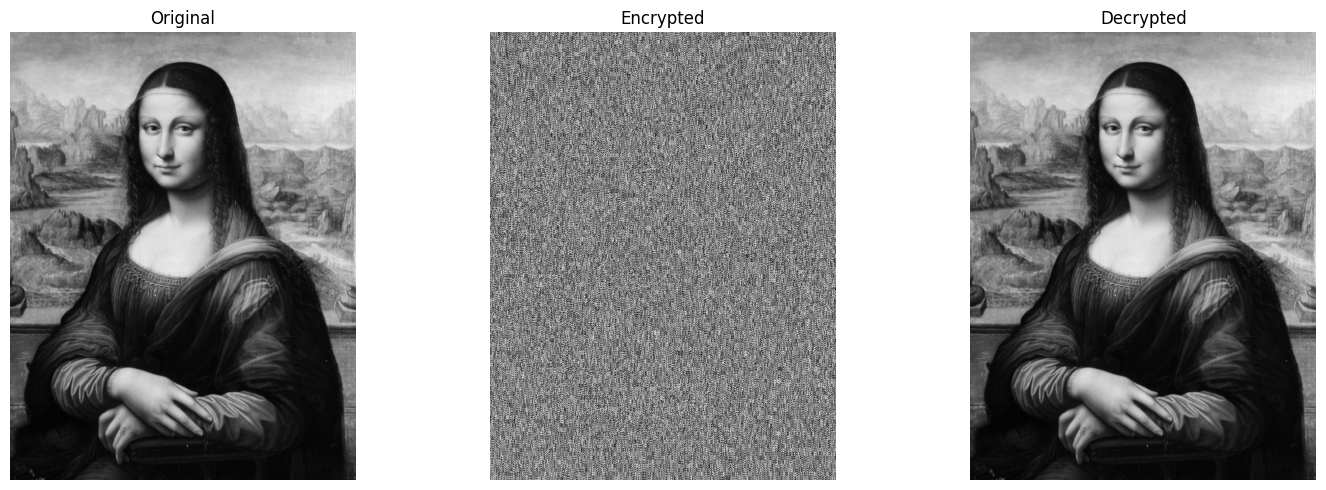

In [ ]:
from PIL import Image
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, suffix, title in zip(axes,
    ['original', 'encrypted', 'decrypted'],
    ['Original', 'Encrypted', 'Decrypted']):
    ax.imshow(Image.open(f"{image_path.rsplit('.',1)[0]}_{suffix}.png"), cmap='gray')
    ax.set_title(title)
    ax.axis('off')
plt.tight_layout()
plt.show()

In [ ]:
from google.colab import files
stem = image_path.rsplit('.', 1)[0]
files.download(f'{stem}_original.png')
files.download(f'{stem}_encrypted.png')
files.download(f'{stem}_decrypted.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Metric                           Original   Encrypted   Decrypted
----------------------------------------------------------------
Corr (horizontal  )               0.993796     -0.004505      0.993796  
Corr (vertical    )               0.995184     -0.002404      0.995184  
Corr (diagonal    )               0.989848      0.007790      0.989848  


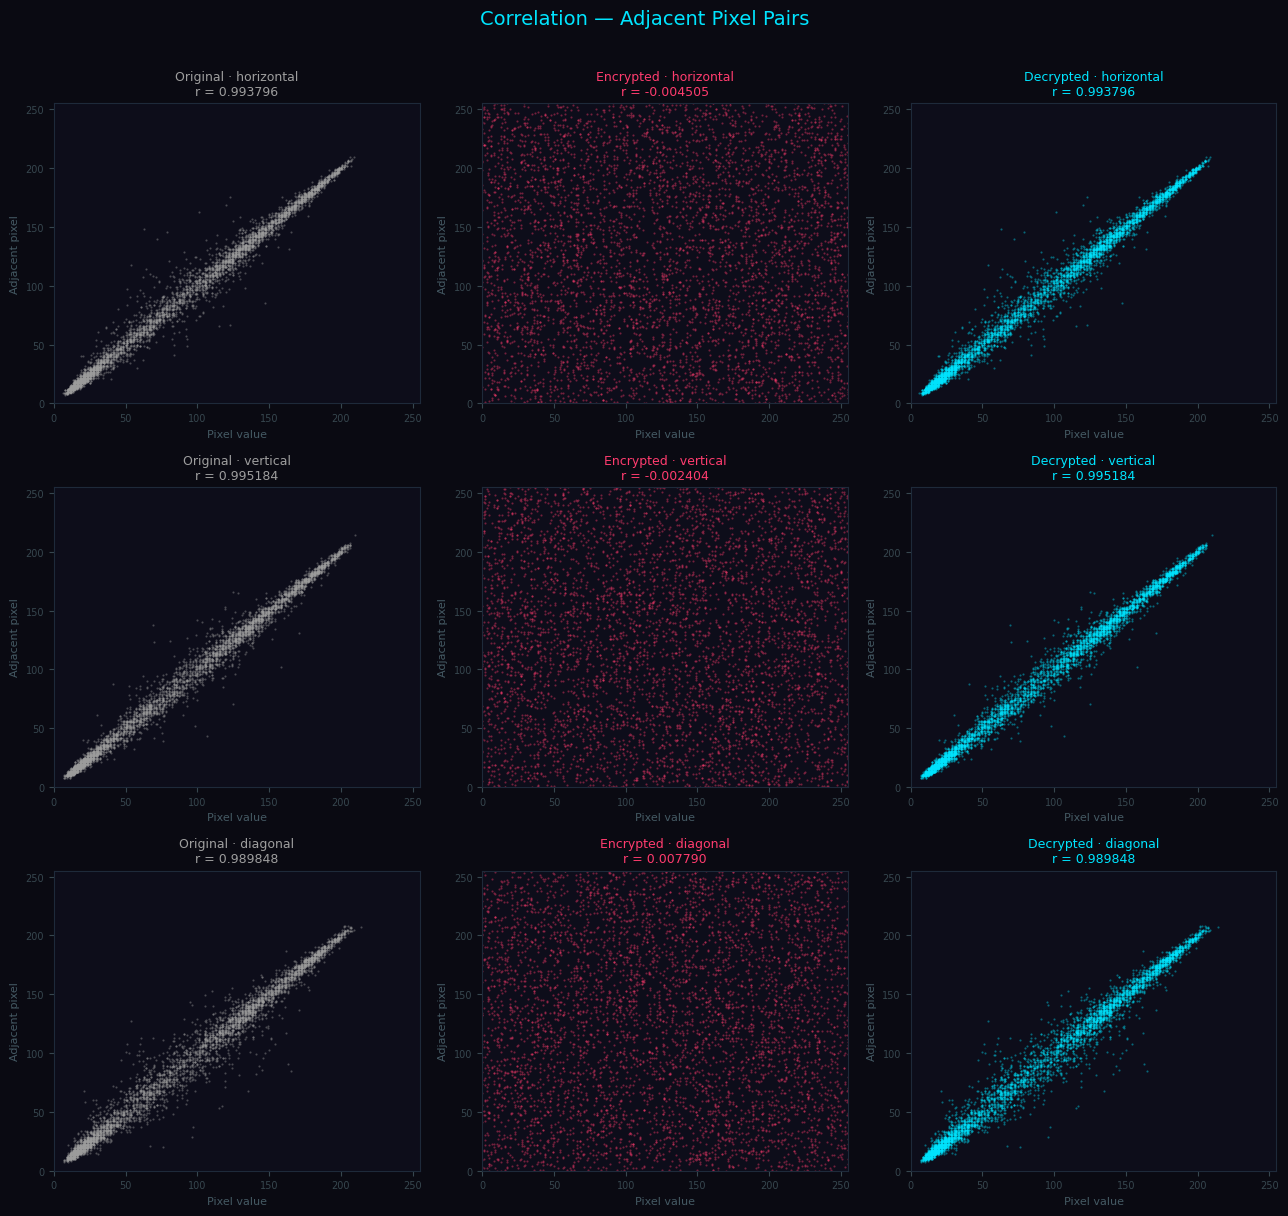

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def sample_pairs(img, direction='horizontal', n=5000):
    H, W = img.shape
    np.random.seed(42)
    if direction == 'horizontal':
        r = np.random.randint(0, H,   n); c = np.random.randint(0, W-1, n)
        return img[r, c].astype(float), img[r, c+1].astype(float)
    elif direction == 'vertical':
        r = np.random.randint(0, H-1, n); c = np.random.randint(0, W,   n)
        return img[r, c].astype(float), img[r+1, c].astype(float)
    elif direction == 'diagonal':
        r = np.random.randint(0, H-1, n); c = np.random.randint(0, W-1, n)
        return img[r, c].astype(float), img[r+1, c+1].astype(float)

def correlation(x, y):
    xm, ym = x - x.mean(), y - y.mean()
    denom = np.sqrt((xm**2).sum() * (ym**2).sum())
    return float(np.dot(xm, ym) / denom) if denom != 0 else 0.0

stem      = image_path.rsplit('.', 1)[0]
orig      = np.array(Image.open(f'{stem}_original.png').convert('L'))
encrypted = np.array(Image.open(f'{stem}_encrypted.png').convert('L'))
decrypted = np.array(Image.open(f'{stem}_decrypted.png').convert('L'))

images_dict = {'Original': orig, 'Encrypted': encrypted, 'Decrypted': decrypted}
directions  = ['horizontal', 'vertical', 'diagonal']
clrs        = {'Original': '#9e9e9e', 'Encrypted': '#ff3c6e', 'Decrypted': '#00e5ff'}

corr_results = {name: {d: correlation(*sample_pairs(im, d)) for d in directions}
                for name, im in images_dict.items()}

# Print table
print(f"{'Metric':<30} {'Original':>10}  {'Encrypted':>10}  {'Decrypted':>10}")
print('-' * 64)
for d in directions:
    vals = ''.join(f'{corr_results[n][d]:>12.6f}  ' for n in ['Original','Encrypted','Decrypted'])
    print(f'Corr ({d:<12})           {vals}')

# Scatter plots
fig, axes = plt.subplots(3, 3, figsize=(13, 12))
fig.patch.set_facecolor('#0a0a12')
fig.suptitle('Correlation — Adjacent Pixel Pairs', color='#00e5ff', fontsize=14, y=1.01)
for col, (name, im) in enumerate(images_dict.items()):
    for row, direction in enumerate(directions):
        ax = axes[row][col]
        ax.set_facecolor('#0d0d1a')
        x, y = sample_pairs(im, direction)
        ax.scatter(x, y, s=0.3, alpha=0.4, color=clrs[name], rasterized=True)
        r = corr_results[name][direction]
        ax.set_title(f'{name} · {direction}\nr = {r:.6f}', color=clrs[name], fontsize=9)
        ax.set_xlabel('Pixel value', color='#455a64', fontsize=8)
        ax.set_ylabel('Adjacent pixel', color='#455a64', fontsize=8)
        ax.tick_params(colors='#37474f', labelsize=7)
        ax.set_xlim(0, 255); ax.set_ylim(0, 255)
        for spine in ax.spines.values(): spine.set_edgecolor('#1e2a3a')
plt.tight_layout()
plt.show()

  SECURITY METRICS
  Corr (horizontal  )       0.994435     -0.004336      0.994435  
  Corr (vertical    )       0.994747      0.000585      0.994747  
  Corr (diagonal    )       0.990672      0.002196      0.990672  
--------------------------------------------------------------
  Entropy  (Original    )     7.359347 bits
  Entropy  (Encrypted   )     7.999563 bits
  Entropy  (Decrypted   )     7.359347 bits
--------------------------------------------------------------
  NPCR  (orig vs enc)      99.5642 %   (ideal ≈ 99.6%)
  UACI  (orig vs enc)      33.4393 %   (ideal ≈ 33.4%)


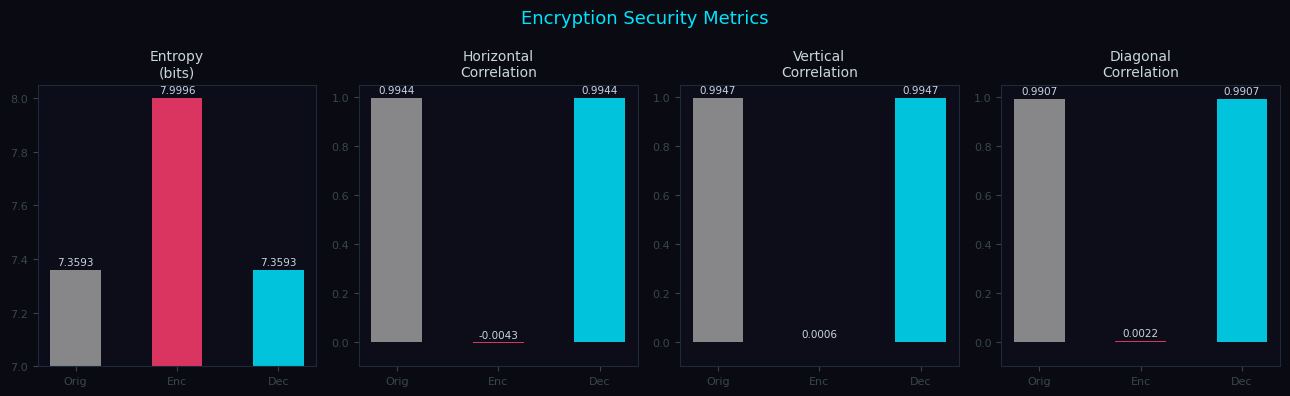

In [ ]:
def entropy(arr):
    hist, _ = np.histogram(arr.flatten(), bins=256, range=(0,255))
    hist = hist[hist > 0].astype(float)
    p = hist / hist.sum()
    return float(-np.sum(p * np.log2(p)))

def npcr_uaci(img1, img2):
    diff = img1.astype(int) != img2.astype(int)
    npcr = 100.0 * diff.sum() / diff.size
    uaci = 100.0 * np.abs(img1.astype(int) - img2.astype(int)).sum() / (255 * diff.size)
    return npcr, uaci

npcr, uaci = npcr_uaci(orig, encrypted)

print('=' * 62)
print('  SECURITY METRICS')
print('=' * 62)
for d in directions:
    vals = ''.join(f'{corr_results[n][d]:>12.6f}  ' for n in ['Original','Encrypted','Decrypted'])
    print(f'  Corr ({d:<12})   {vals}')
print('-' * 62)
for name, im in images_dict.items():
    print(f'  Entropy  ({name:<12})   {entropy(im):>10.6f} bits')
print('-' * 62)
print(f'  NPCR  (orig vs enc)   {npcr:>10.4f} %   (ideal ≈ 99.6%)')
print(f'  UACI  (orig vs enc)   {uaci:>10.4f} %   (ideal ≈ 33.4%)')
print('=' * 62)

# Bar chart dashboard
metrics = [
    ('Entropy\n(bits)',         [entropy(im) for im in images_dict.values()],              7.0, 8.05),
    ('Horizontal\nCorrelation', [corr_results[n]['horizontal'] for n in images_dict],      -0.1, 1.05),
    ('Vertical\nCorrelation',   [corr_results[n]['vertical']   for n in images_dict],      -0.1, 1.05),
    ('Diagonal\nCorrelation',   [corr_results[n]['diagonal']   for n in images_dict],      -0.1, 1.05),
]
fig = plt.figure(figsize=(13, 4))
fig.patch.set_facecolor('#0a0a12')
fig.suptitle('Encryption Security Metrics', color='#00e5ff', fontsize=13)
for i, (title, vals, ymin, ymax) in enumerate(metrics):
    ax = fig.add_subplot(1, 4, i+1)
    ax.set_facecolor('#0d0d1a')
    bars = ax.bar(['Orig','Enc','Dec'], vals, color=['#9e9e9e','#ff3c6e','#00e5ff'], alpha=0.85, width=0.5)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+(ymax-ymin)*0.01,
                f'{val:.4f}', ha='center', va='bottom', color='#c8d6e0', fontsize=7.5)
    ax.set_title(title, color='#c8d6e0', fontsize=10)
    ax.set_ylim(ymin, ymax)
    ax.tick_params(colors='#37474f', labelsize=8)
    for spine in ax.spines.values(): spine.set_edgecolor('#1e2a3a')
plt.tight_layout()
plt.show()